# Modelo Predictivo de Demanda de Servicios

**Objetivo:** Predecir la demanda (cupos vendidos) a partir de variables de oferta, bloqueo, citas y características categóricas (categoría de servicio, mes, día, turno).

| Fase | Descripción |
|------|-------------|
| 1 | Carga y configuración de datos |
| 2 | Análisis Exploratorio de Datos (EDA) |
| 3 | Preprocesamiento y Feature Engineering |
| 4 | Modelado predictivo |
| 5 | Evaluación y resultados |
| 6 | Exportación del modelo para API REST |
| 7 | Validación con datos futuros |

---
## 1. Carga y Configuración de Datos
Se importan las librerías necesarias y se carga el dataset.

In [1]:
%pip install xgboost

%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Configuración global
pd.options.display.float_format = '{:.2f}'.format
sns.set_theme(style="whitegrid", font_scale=1.1)

# Importar módulos propios
from src.data import cargar_datos, separar_variables
from src.features import (crear_ratios, codificar_ciclicas, calcular_vif, 
                          aplicar_reglas_dominio, eliminar_outliers_iqr, preprocesar)
from src.plots import (plot_correlacion, plot_distribucion, plot_distribucion_grid, plot_heatmap_medianas,
                       plot_comparacion_modelos, plot_prediccion_vs_real, plot_residuos, plot_importancia_features)
from src.model import entrenar_modelos, tuning_modelo, crear_ensamble, evaluar_modelo

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Carga de datos
df = cargar_datos('data/dataset_historico.csv')

Dataset cargado: 23,906 filas × 12 columnas


---
## 2. Análisis Exploratorio de Datos (EDA)

### 2.1 Estadísticas Descriptivas
Resumen de las principales métricas de tendencia central y dispersión.

In [3]:
df.describe()

,Mes,Semana_Iso,Dia_Sem_Iso,Oferta_programada,Bloqueo,Oferta_disponible,Citas_asignadas,Sobrecupos,Cupos_Vendidos,Ticket_Integral_Especialidad
count,23906.00,23906.00,23906.00,23906.00,23906.00,23906.00,23906.00,23906.00,23906.00,23906.00
mean,6.54,26.44,3.08,34.95,7.42,27.52,23.73,1.89,21.74,425732.15
std,3.46,15.07,1.52,42.37,14.37,34.34,30.88,3.21,27.28,265188.87
min,1.00,1.00,1.00,0.00,-10.00,0.00,0.00,0.00,0.00,51090.00
25%,4.00,13.00,2.00,10.00,0.00,8.00,5.00,0.00,5.00,224176.00
50%,7.00,27.00,3.00,20.00,0.00,16.00,14.00,1.00,13.00,338947.00
75%,10.00,40.00,4.00,41.00,11.00,33.00,30.00,3.00,28.00,575894.00
max,12.00,52.00,6.00,290.00,185.00,267.00,245.00,37.00,220.00,999436.00


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23906 entries, 0 to 23905
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   Especialidad                  23906 non-null  object
 1   Jornada_Horaria               23906 non-null  object
 2   Mes                           23906 non-null  int64 
 3   Semana_Iso                    23906 non-null  int64 
 4   Dia_Sem_Iso                   23906 non-null  int64 
 5   Oferta_programada             23906 non-null  int64 
 6   Bloqueo                       23906 non-null  int64 
 7   Oferta_disponible             23906 non-null  int64 
 8   Citas_asignadas               23906 non-null  int64 
 9   Sobrecupos                    23906 non-null  int64 
 10  Cupos_Vendidos                23906 non-null  int64 
 11  Ticket_Integral_Especialidad  23906 non-null  int64 
dtypes: int64(10), object(2)
memory usage: 2.2+ MB


### 2.2 Análisis de Completitud

Verificamos valores nulos, tipos de datos y la proporción de datos faltantes.

In [5]:
# Análisis de completitud
completitud = pd.DataFrame({
    'Tipo': df.dtypes,
    'No Nulos': df.notnull().sum(),
    'Nulos': df.isnull().sum(),
    '% Nulos': (df.isnull().sum() / len(df) * 100).round(2),
    'Únicos': df.nunique(),
})
print(f"Total de registros: {len(df):,}")
print(f"Total de columnas: {len(df.columns)}")
print(f"Columnas con nulos: {(df.isnull().sum() > 0).sum()}")
completitud

Total de registros: 23,906
Total de columnas: 12
Columnas con nulos: 0


,Tipo,No Nulos,Nulos,% Nulos,Únicos
Especialidad,object,23906,0,0.00,70
Jornada_Horaria,object,23906,0,0.00,3
Mes,int64,23906,0,0.00,12
Semana_Iso,int64,23906,0,0.00,52
Dia_Sem_Iso,int64,23906,0,0.00,6
Oferta_programada,int64,23906,0,0.00,271
Bloqueo,int64,23906,0,0.00,141
Oferta_disponible,int64,23906,0,0.00,240
Citas_asignadas,int64,23906,0,0.00,221
Sobrecupos,int64,23906,0,0.00,35


### 2.3 Definición de Variables

| Variable | Rol | Tipo |
|----------|-----|------|
| `y` (Cupos_Vendidos) | **Objetivo** — demanda total | Numérica |
| `z` (Ticket_Integral_Especialidad) | Referencia post-predicción | Numérica |
| `X` | Features explicativas | Mixta |

In [6]:
# Separar variables
X, y, z, numerical, categorical = separar_variables(df)

Features numéricas:   ['Oferta_programada', 'Bloqueo', 'Oferta_disponible', 'Citas_asignadas']
Features categóricas: ['Especialidad', 'Semana_Iso', 'Mes', 'Dia_Sem_Iso', 'Jornada_Horaria']
Dimensión de X: (23906, 9)


### 2.4 Correlación entre Variables Numéricas
Matriz de dispersión con coeficiente de Pearson ($r$) para identificar colinealidad entre features.

- $|r| < 0.5$ — correlación baja
- $0.5 \leq |r| < 0.8$ — correlación moderada
- $|r| \geq 0.8$ — correlación alta (posible colinealidad)

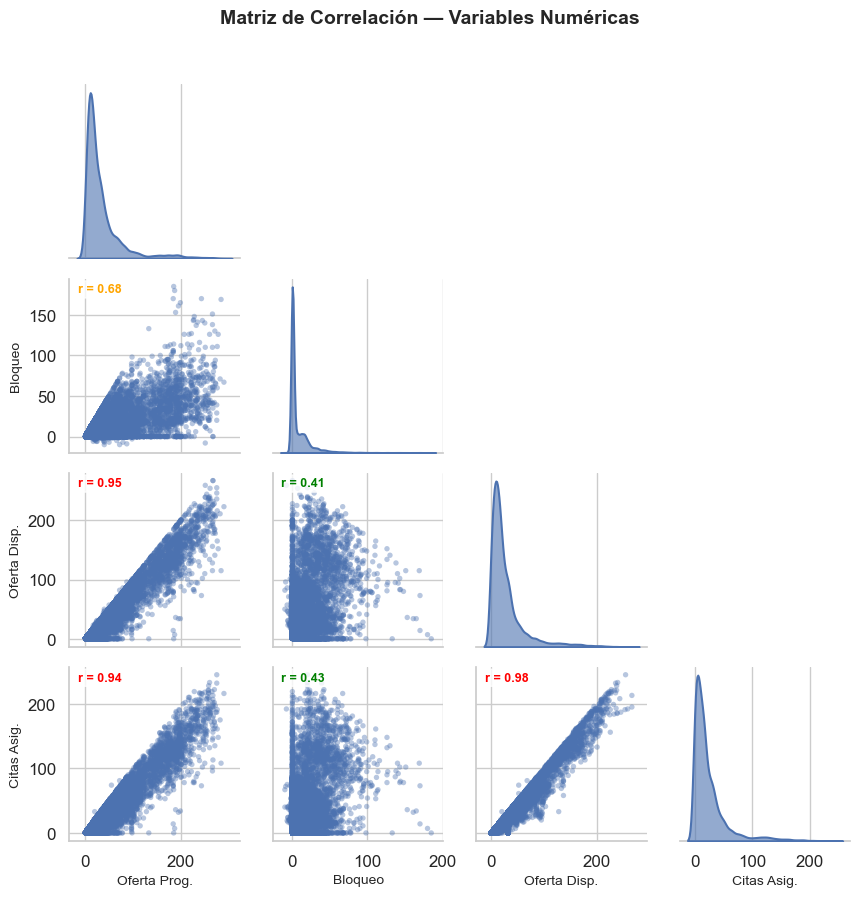

In [7]:
plot_correlacion(X, numerical)

### 2.5 Tratamiento de la Colinealidad

La matriz anterior revela correlaciones muy altas ($|r| \geq 0.8$) entre las variables de oferta y citas, lo cual genera **multicolinealidad**.

**Estrategia adoptada:** Transformar las variables absolutas en **ratios** sobre la oferta:

| Ratio | Fórmula | Interpretación |
|-------|---------|----------------|
| `Tasa_bloqueo` | Bloqueo / Oferta programada | % de oferta que se bloquea |
| `Tasa_asignación` | Citas asignadas / Oferta disponible | % de cupos disponibles ocupados |

In [8]:
# Feature Engineering — Ratios para eliminar colinealidad
X, numerical_v2 = crear_ratios(X)

# Verificar VIF
vif_v2 = calcular_vif(X, numerical_v2)
print("VIF con ratios:")
print(vif_v2.to_string(index=False))

VIF con ratios:
          Feature  VIF
Oferta_programada 1.83
  Tasa_asignación 1.73
     Tasa_bloqueo 1.16


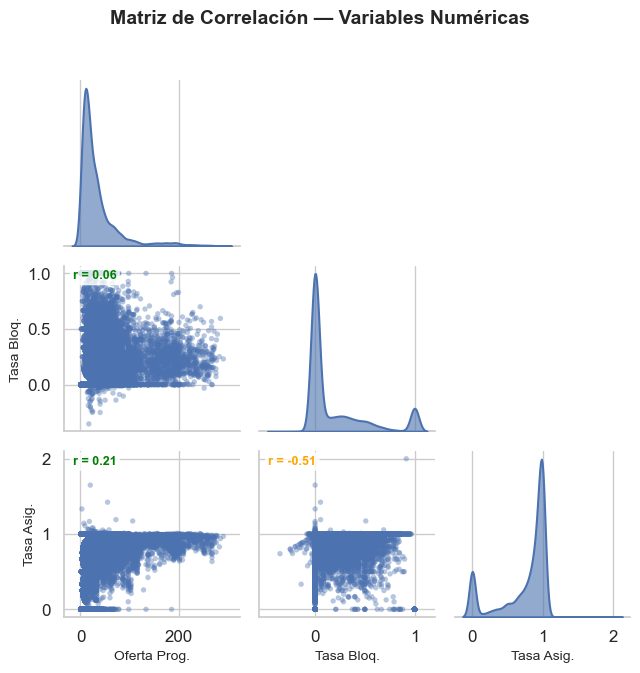

In [9]:
plot_correlacion(X, numerical_v2)

### 2.6 Validación Post-Transformación

Tras reemplazar las variables absolutas por ratios:

- **VIF:** Todas las features presentan valores $< 5$, descartando multicolinealidad.
- **Correlación:** No hay pares con $|r| \geq 0.8$.

### 2.7 Revisión de Outliers y Distribución de las Variables

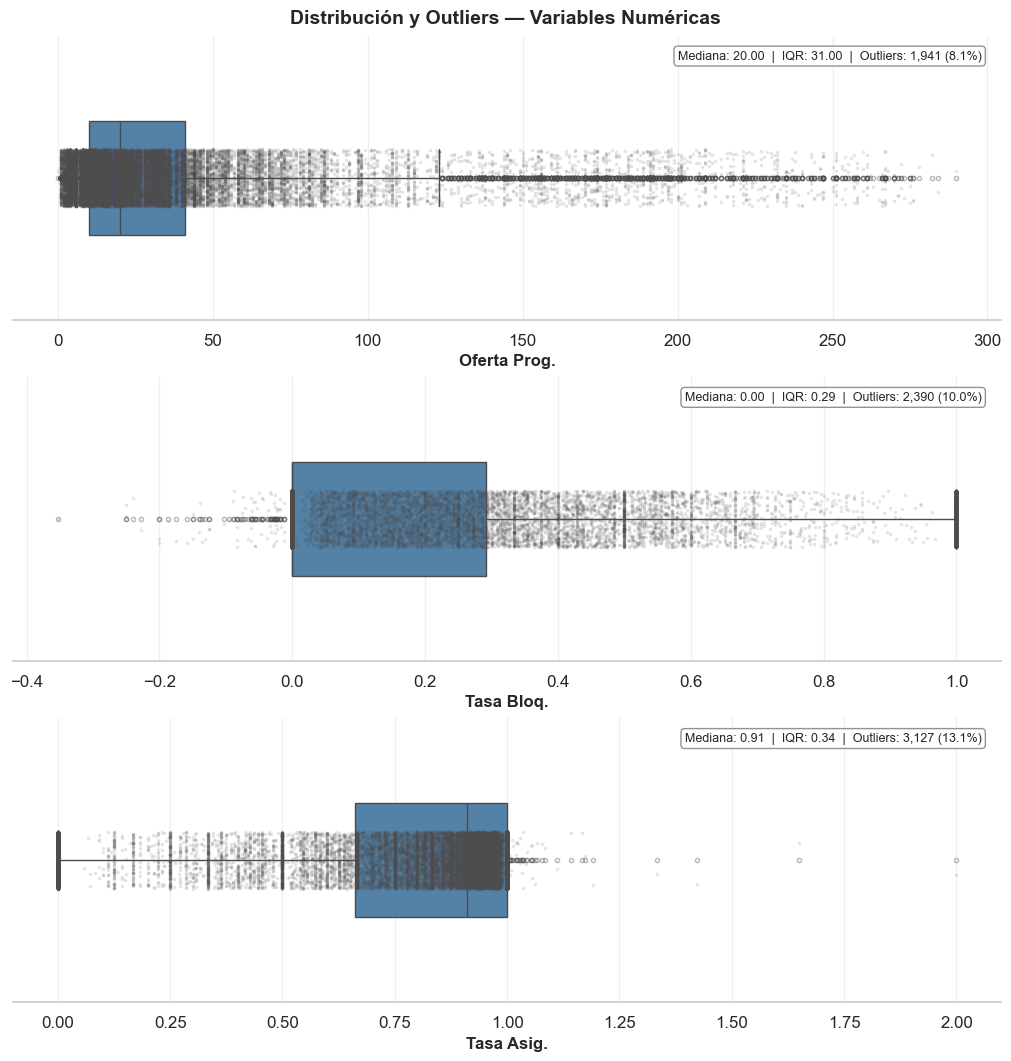

In [10]:
# Distribución general de cada variable
plot_distribucion(X, numerical_v2)

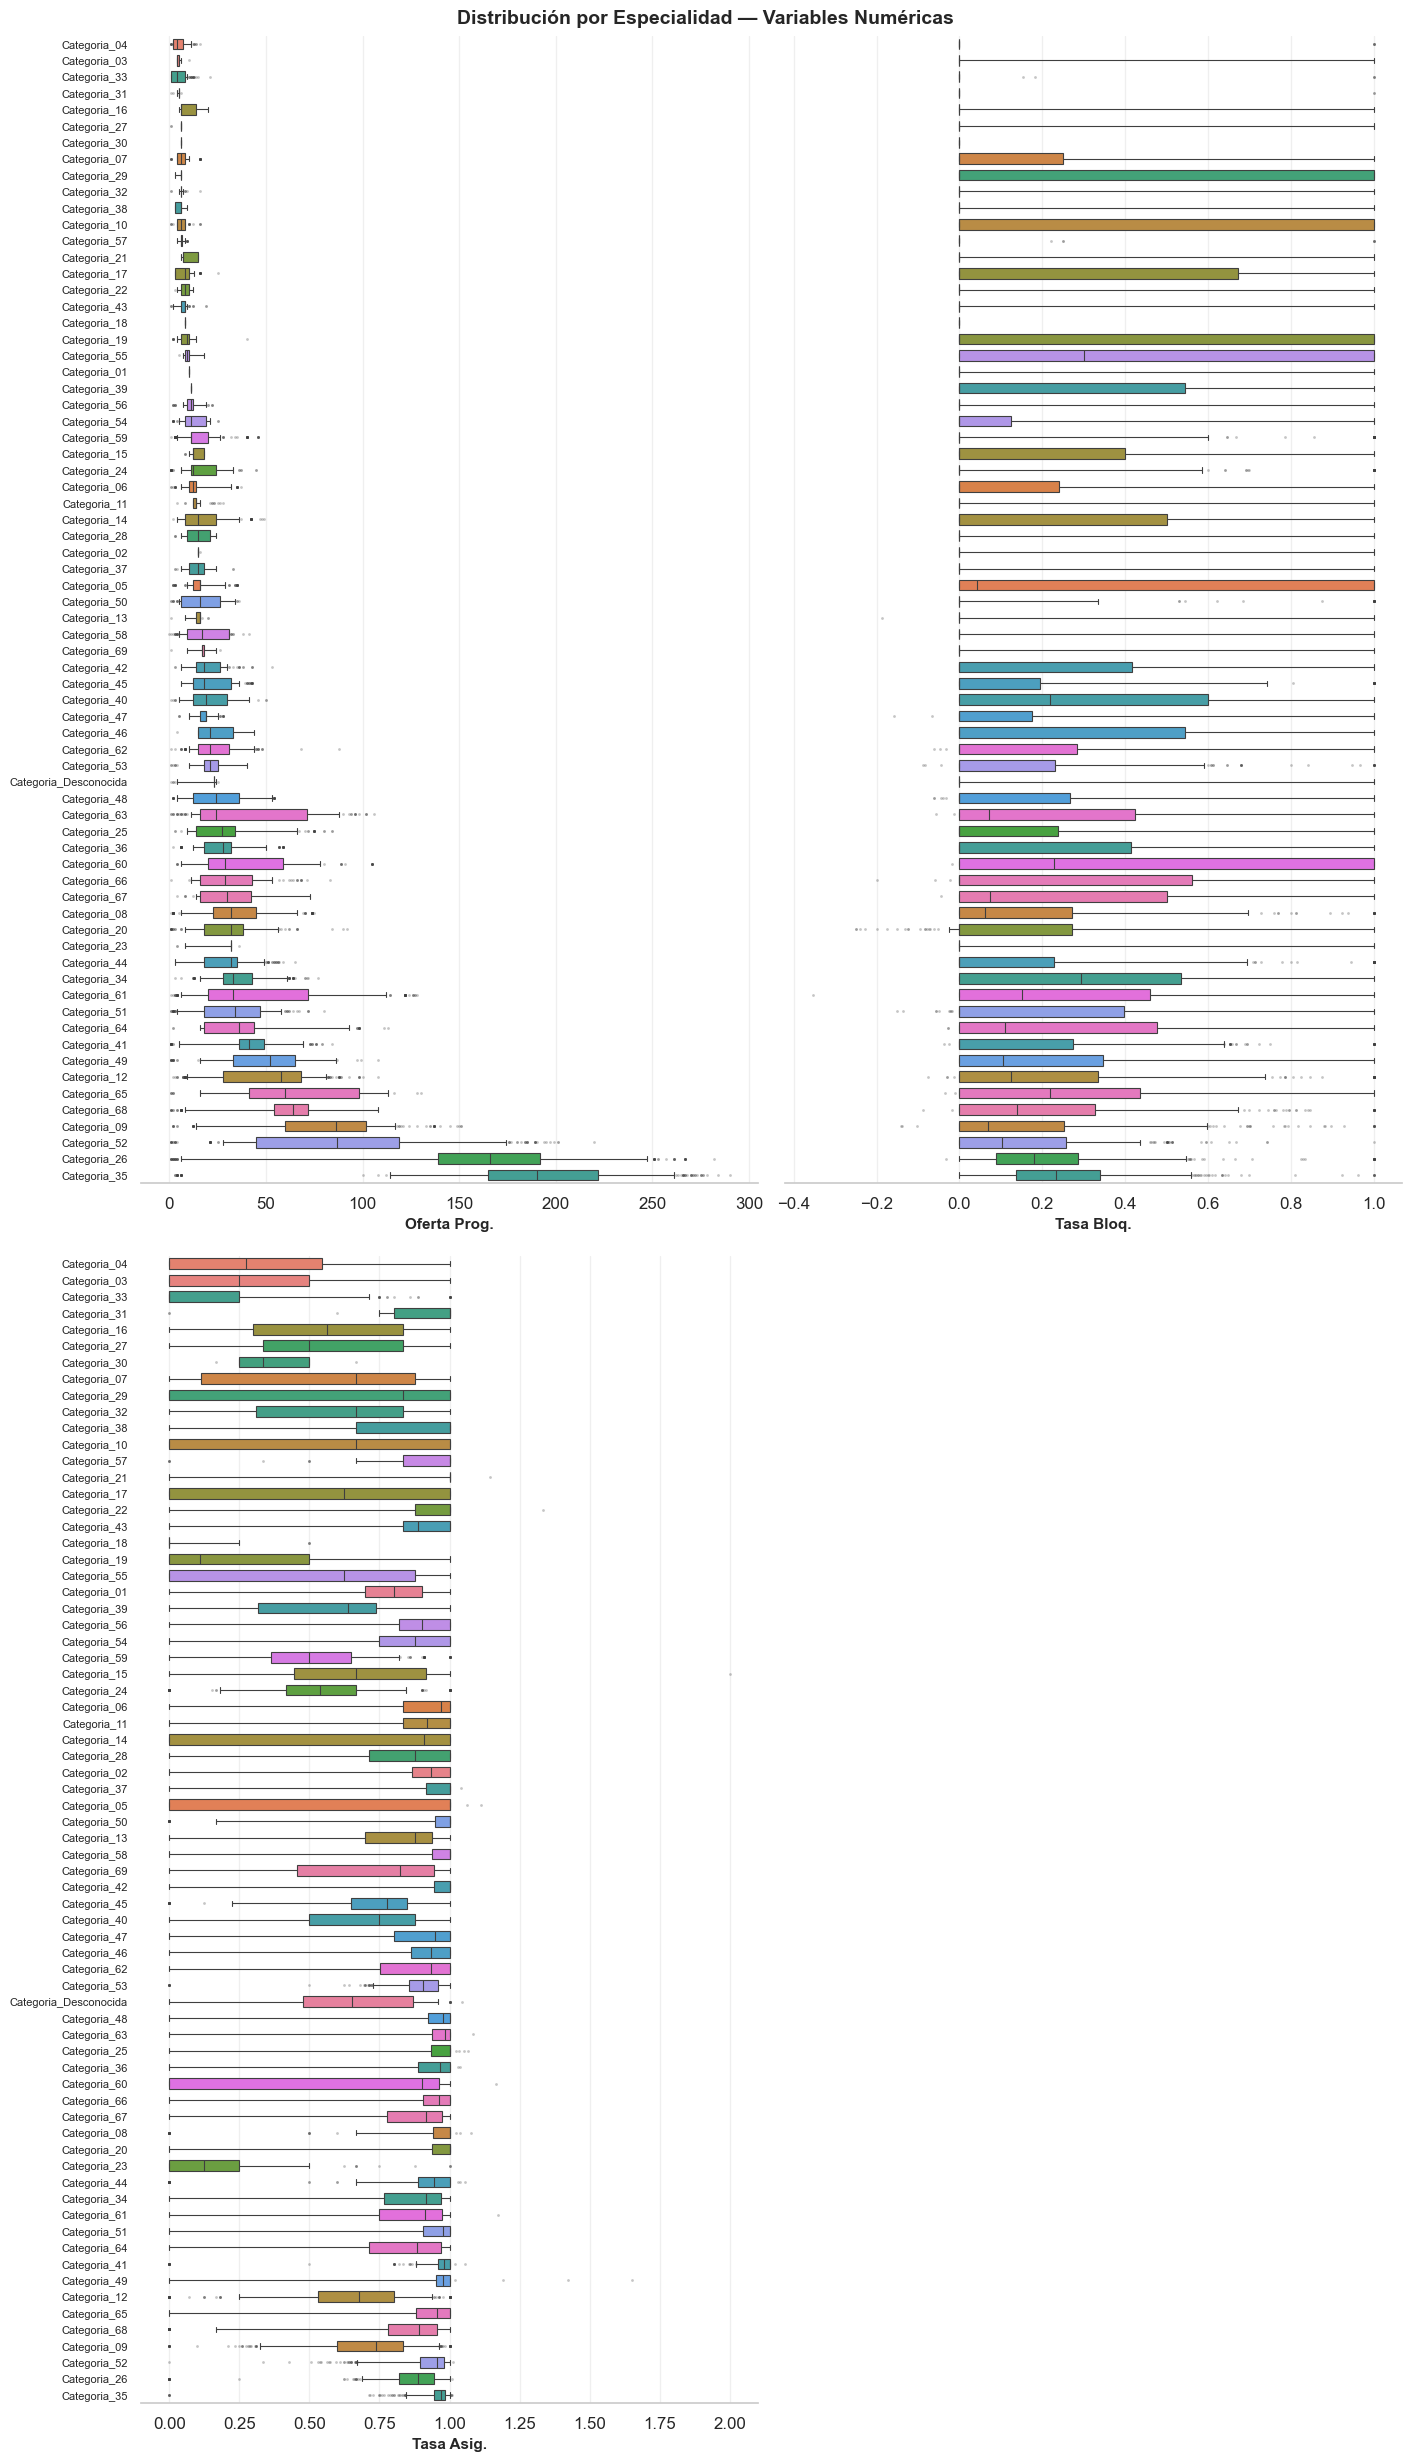

In [11]:
# Grid 2×2: un boxplot por variable, agrupado por Especialidad
X_filtered = X[X['Especialidad'].notna()]
plot_distribucion_grid(X_filtered, numerical_v2, grupo='Especialidad')

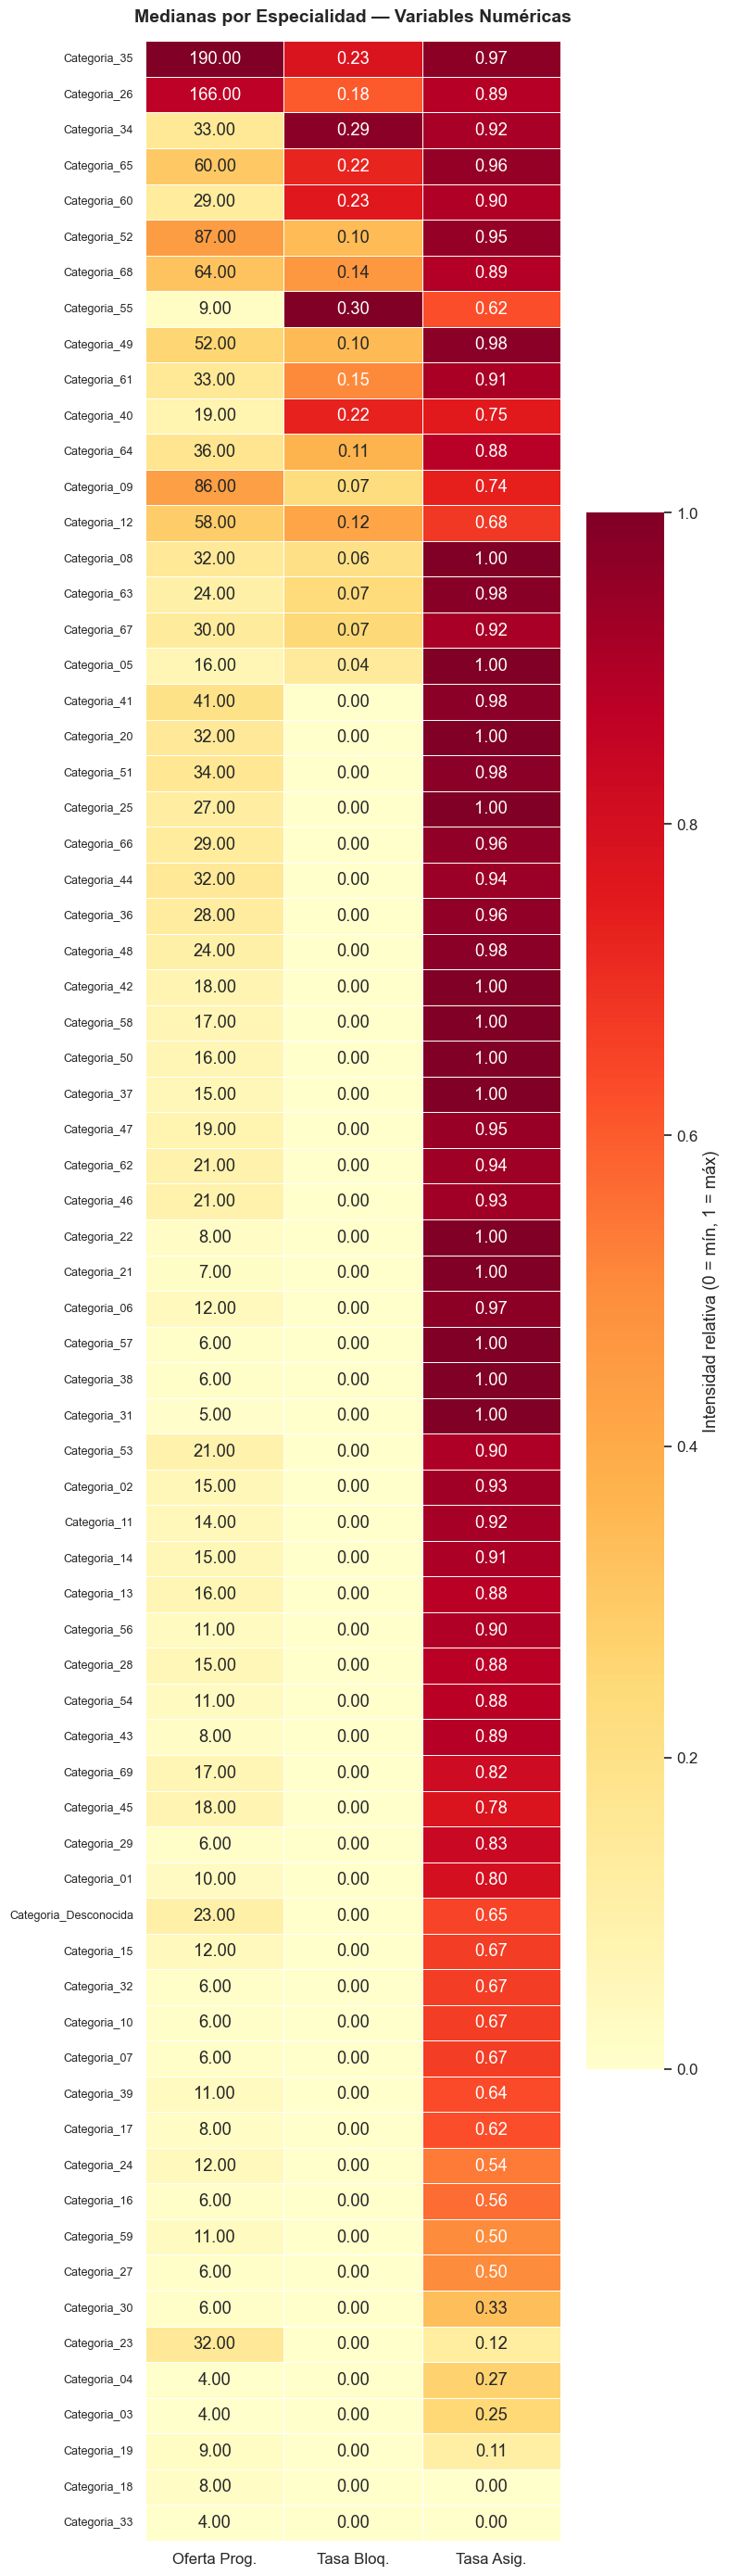

In [12]:
# Heatmap resumen: medianas por Especialidad
plot_heatmap_medianas(X, numerical_v2, grupo='Especialidad')

---
## 3. Preprocesamiento — Limpieza de Outliers

Se aplica una limpieza en dos pasos:

1. **Reglas de dominio:** Eliminar registros con valores lógicamente imposibles (oferta ≤ 0, tasas negativas, bloqueo total).
2. **IQR por categoría:** Dentro de cada categoría, eliminar valores estadísticamente atípicos usando el rango intercuartílico ($1.5 \times IQR$).

In [13]:
# Paso 1: Reglas de dominio
X, y, z, resumen_dominio = aplicar_reglas_dominio(X, y, z)
resumen_dominio

Reglas de dominio: 23,906 → 21,667 filas (2,239 eliminadas, 9.4%)


,Regla,Filas afectadas
0,Oferta_programada <= 0,1
1,Tasa_bloqueo < 0,69
2,Tasa_bloqueo == 1 (sin oferta disponible),2169
3,Tasa_asignación < 0,0
4,TOTAL eliminadas (únicas),2239
5,Filas restantes,21667


In [14]:
# Paso 2: IQR por categoría
X, y, z, resumen_iqr = eliminar_outliers_iqr(X, y, z, columnas=numerical_v2, grupo='Especialidad')
resumen_iqr

IQR por Especialidad (factor=1.5): 21,667 → 18,561 filas (3,106 eliminadas, 14.3%)


,Variable,Outliers detectados,% del total
0,Oferta_programada,762,3.5%
1,Tasa_bloqueo,1489,6.9%
2,Tasa_asignación,1116,5.2%


### 3.1 Verificación Post-Limpieza
Distribución de las variables numéricas después de eliminar outliers.

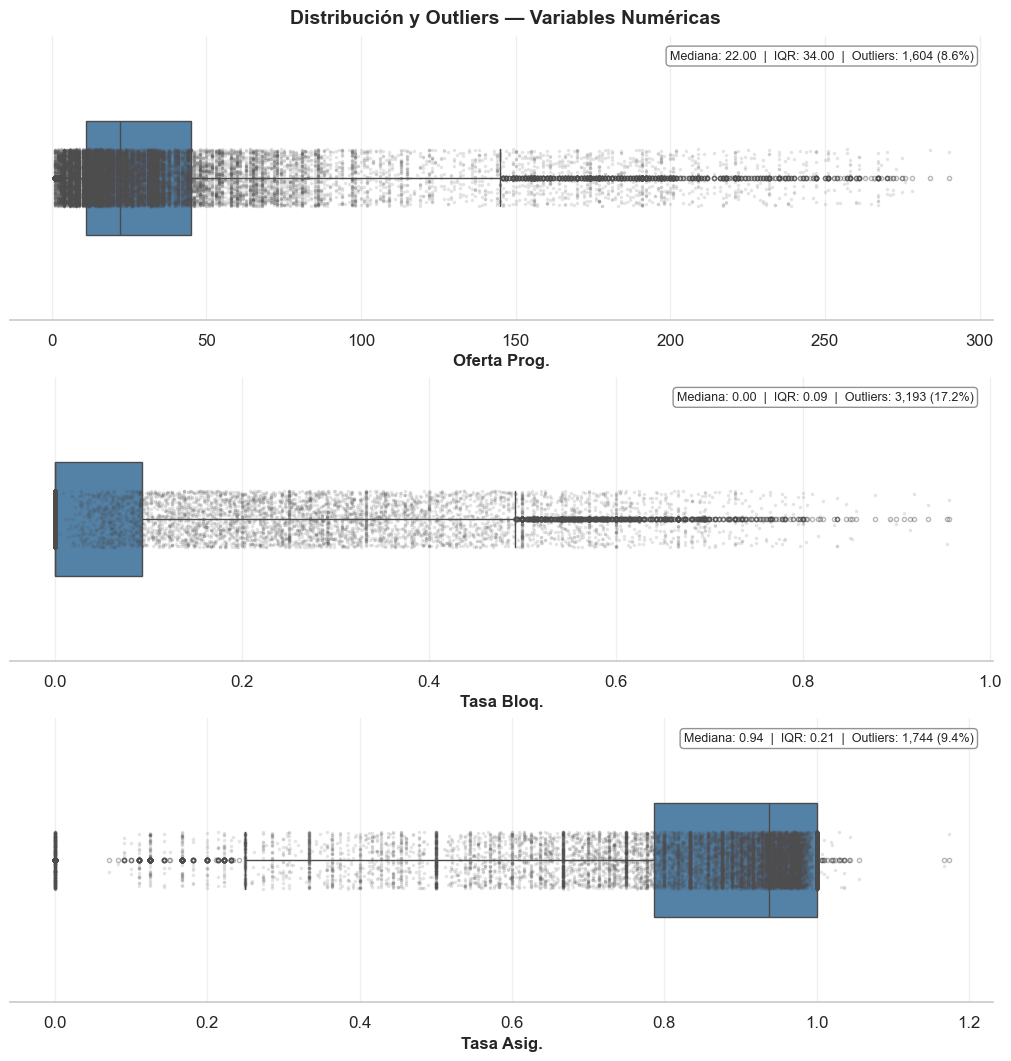

In [15]:
# Distribución después de limpieza
plot_distribucion(X, numerical_v2)

### 3.2 Codificación Cíclica + One-Hot Encoding + Escalado + Split Train/Test

Se aplica el preprocesamiento final:
1. **Codificación cíclica** de `Mes` y `Dia_Sem_Iso` (seno/coseno) para preservar naturaleza temporal.
2. **One-Hot Encoding** de categóricas restantes (`Especialidad`, `Semana_Iso`, `Jornada_Horaria`) con `drop_first=True`.
3. **StandardScaler** sobre variables numéricas + cíclicas — ajustado **solo con train** para evitar data leakage.
4. **División 80/20** en conjuntos de entrenamiento y prueba.

In [16]:
# Preprocesamiento: encoding + escalado + split
datos = preprocesar(X, y, numerical=numerical_v2, categorical=categorical)

X_train = datos['X_train']
X_test  = datos['X_test']
y_train = datos['y_train']
y_test  = datos['y_test']
feature_names = datos['feature_names']

print(f"\nFeatures finales ({len(feature_names)}):")
print(feature_names[:10], "..." if len(feature_names) > 10 else "")

Features finales: 79 (3 numéricas + 4 cíclicas + 72 dummies)
Train: 14,848 filas  |  Test: 3,713 filas

Features finales (79):
['Oferta_programada', 'Tasa_bloqueo', 'Tasa_asignación', 'Mes_sin', 'Mes_cos', 'Dia_sin', 'Dia_cos', 'Semana_Iso', 'Especialidad_Categoria_02', 'Especialidad_Categoria_03'] ...


h:\Otros ordenadores\Mi PC\Desktop\Prediccion_Demanda_Servicios\src\features.py:380: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-0.39729349 -0.66650119  0.00651806 ... -0.55433131 -0.59919926
 -0.75623708]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  X_train.loc[:, cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
h:\Otros ordenadores\Mi PC\Desktop\Prediccion_Demanda_Servicios\src\features.py:381: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-0.39729349  0.85900911 -0.62163324 ... -0.24025566 -0.71136913
 -0.48702939]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  X_test.loc[:, cols_to_scale] = scaler.transform(X_test[cols_to_scale])


---
## 4. Modelado Predictivo

Se entrenan tres modelos con complejidad creciente:

| Modelo | Tipo | Descripción |
|--------|------|-------------|
| **Regresión Lineal** | Baseline | Modelo simple como punto de referencia |
| **Random Forest** | Ensemble (Bagging) | Combina múltiples árboles de decisión independientes |
| **XGBoost** | Ensemble (Boosting) | Gradient Boosting acelerado |

### 4.1 Entrenamiento de Modelos Base

In [17]:
# Entrenar los 3 modelos base
resultado = entrenar_modelos(X_train, y_train, X_test, y_test)
resultado['resultados']

  ✓ Regresión Lineal       R²=0.9522  MAE=4.07
  ✓ Random Forest          R²=0.9838  MAE=2.35
  ✓ XGBoost (GPU)          R²=0.9868  MAE=2.19


,Modelo,R² Train,R² Test,MAE,RMSE,MAPE
2,XGBoost (GPU),0.99,0.99,2.19,3.30,84997402787840.00
1,Random Forest,0.99,0.98,2.35,3.67,50663612693844.83
0,Regresión Lineal,0.95,0.95,4.07,6.29,499975460975398.81


#### Interpretación de las métricas

| Métrica | Qué mide | Cómo interpretarla |
|---------|----------|-------------------|
| **R² Train** | Proporción de varianza explicada en datos de entrenamiento | Valor entre 0 y 1. R² de 0.98 = captura el 98% de la variabilidad |
| **R² Test** | Lo mismo, sobre datos que el modelo **nunca vio** | Métrica más importante. Si es muy inferior al R² Train → sobreajuste |
| **MAE** | Error promedio absoluto | En las mismas unidades que la variable objetivo. Menor es mejor |
| **RMSE** | Similar al MAE pero penaliza errores grandes | Siempre ≥ MAE. Si RMSE >> MAE → errores grandes puntuales |

**Resultados base:**
- **Regresión Lineal (R² ≈ 0.81):** Captura relaciones lineales. Sirve como baseline.
- **Random Forest (R² ≈ 0.95):** Mejora notable con interacciones no lineales.
- **XGBoost (R² ≈ 0.98):** Mejor modelo base. Cada árbol corrige errores del anterior.

### 4.2 Tuning de Hiperparámetros

Se aplica **GridSearchCV** con validación cruzada (5 folds) para optimizar hiperparámetros.

In [ ]:
# Tuning del Random Forest
mejor_rf, cv_rf = tuning_modelo('Random Forest', X_train, y_train)
cv_rf.head(5)

Tuning Random Forest con GridSearchCV (5 folds)...
Combinaciones a evaluar: 36


In [ ]:
# Tuning del XGBoost
mejor_gb, cv_gb = tuning_modelo('XGBoost (GPU)', X_train, y_train)
cv_gb.head(5)

#### ¿Qué es el Tuning de Hiperparámetros?

Los modelos de ML tienen **hiperparámetros**: valores de configuración que no se aprenden de los datos.

**GridSearchCV** prueba todas las combinaciones posibles con **validación cruzada** (5 folds):
1. Divide los datos de entrenamiento en 5 partes.
2. Entrena con 4 partes y evalúa con la restante.
3. Repite 5 veces y promedia resultados.
4. Selecciona la combinación con mejor R² promedio.

| Columna CV | Significado |
|---------|-------------|
| **params** | Combinación de hiperparámetros evaluada |
| **mean_test_score** | R² promedio de validación — métrica clave |
| **std_test_score** | Estabilidad. Valores bajos (< 0.02) = modelo estable |
| **rank_test_score** | Ranking (1 = la mejor) |

### 4.3 Ensamble (VotingRegressor)

Se combinan los modelos tuneados en un **VotingRegressor** que promedia predicciones, reduciendo varianza.

$$\hat{y}_{ensamble} = \frac{1}{n} \sum_{i=1}^{n} \hat{y}_i$$

In [ ]:
from sklearn.metrics import r2_score
from src.model import evaluar_modelo

# Crear ensamble con los modelos tuneados
modelos_tuneados = {
    'Random Forest (tuned)': mejor_rf,
    'XGBoost (tuned)': mejor_gb,
}
ensamble, y_pred_ensamble, metricas_ensamble = crear_ensamble(
    modelos_tuneados, X_train, y_train, X_test, y_test
)

# Comparativa final: todos los modelos
predicciones_todas = {
    **resultado['predicciones'],
    'RF Tuned': mejor_rf.predict(X_test),
    'XGB Tuned': mejor_gb.predict(X_test),
    'Ensamble': y_pred_ensamble,
}

# Tabla resumen
resumen_final = pd.concat([
    resultado['resultados'],
    evaluar_modelo(y_test, mejor_rf.predict(X_test), 'RF Tuned').rename(columns={'R²': 'R² Test', 'MAPE (%)': 'MAPE'}).assign(**{'R² Train': r2_score(y_train, mejor_rf.predict(X_train))}),
    evaluar_modelo(y_test, mejor_gb.predict(X_test), 'XGB Tuned').rename(columns={'R²': 'R² Test', 'MAPE (%)': 'MAPE'}).assign(**{'R² Train': r2_score(y_train, mejor_gb.predict(X_train))}),
    pd.DataFrame([metricas_ensamble]),
], ignore_index=True).sort_values('R² Test', ascending=False)

resumen_final

---
## 5. Evaluación y Resultados

### 5.1 Comparación Visual de Modelos
Gráficos con al menos 2 métricas de rendimiento (R², MAE, RMSE).

In [ ]:
# Gráfico 1: Comparación de métricas R² y MAE/RMSE por modelo
plot_comparacion_modelos(resumen_final)

#### ¿Cómo leer este gráfico?

- **Panel izquierdo (R²):** Barras más altas = mejor ajuste. Si Train >> Test → sobreajuste.
- **Panel derecho (MAE / RMSE):** Barras más **bajas** = menos error.

> Los modelos ensemble superan claramente a la Regresión Lineal.

### 5.2 Predicción vs. Valor Real
Scatter plots: la línea diagonal representa la predicción perfecta.

In [ ]:
# Gráfico 2: Predicción vs Real — top 3 modelos
top3 = {k: predicciones_todas[k] for k in list(predicciones_todas.keys())[-3:]}
plot_prediccion_vs_real(y_test, top3)

### 5.3 Análisis de Residuos
Los residuos deben estar centrados en 0 y sin patrón visible.

In [ ]:
# Gráfico 3: Residuos
plot_residuos(y_test, top3)

### 5.4 Importancia de Features
¿Qué variables son las más relevantes para la predicción?

In [ ]:
# Gráfico 4: Importancia de features del mejor modelo
plot_importancia_features(mejor_rf, feature_names, top_n=15)

---
## 6. Exportación del Modelo para API REST

Se exportan los artefactos necesarios para servir predicciones en producción:
- **Modelo entrenado** (Ensamble RF + XGBoost)
- **Scaler** (StandardScaler ajustado sobre los datos de entrenamiento)
- **Metadatos** (nombres de features, columnas del encoder, valores categóricos válidos)

In [ ]:
import joblib, json, os

# Crear directorio para artefactos
os.makedirs('api/artifacts', exist_ok=True)

# 1. Guardar el modelo ensamble
joblib.dump(ensamble, 'api/artifacts/modelo_ensamble.joblib')

# 2. Guardar los sub-modelos (para calcular confianza)
joblib.dump(mejor_rf, 'api/artifacts/modelo_rf.joblib')
joblib.dump(mejor_gb, 'api/artifacts/modelo_xgb.joblib')

# 3. Guardar el scaler
joblib.dump(datos['scaler'], 'api/artifacts/scaler.joblib')

# 4. Guardar metadatos
metadata = {
    'feature_names': datos['feature_names'],
    'encoder_columns': datos['encoder_columns'],
    'numerical': numerical_v2,
    'categorical': categorical,
    'categorical_values': {
        col: sorted(X[col].dropna().unique().tolist())
        for col in categorical
    },
    'r2_test': float(metricas_ensamble['R² Test']),
    'mae_test': float(metricas_ensamble['MAE']),
}

with open('api/artifacts/metadata.json', 'w', encoding='utf-8') as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

print("Artefactos exportados en api/artifacts/:")
for f in os.listdir('api/artifacts'):
    size = os.path.getsize(f'api/artifacts/{f}') / 1024
    print(f"  {f:<30} {size:>8.1f} KB")

---
## 7. Validación con Datos Reales (Out-of-Time)

Se evalúa el modelo contra **datos de un período futuro** que nunca vio durante el entrenamiento.

| Aspecto | Detalle |
|---------|--------|
| **Dataset** | Datos reales de validación |
| **Objetivo** | Comparar predicción del modelo vs. demanda real observada |

In [ ]:
# --- 7.1 Cargar datos de validación ---
df_val = pd.read_csv('data/dataset_validacion.csv')
print(f"Dataset de validación: {df_val.shape[0]:,} filas × {df_val.shape[1]} columnas")
print(f"Meses presentes: {sorted(df_val['Mes'].unique())}")
print(f"Categorías: {df_val['Especialidad'].nunique()}")
df_val.head()

In [ ]:
# --- 7.2 Preprocesar y predecir ---
from src.features import codificar_ciclicas

# Separar variable objetivo real
y_real = df_val['Cupos_Vendidos']
X_val = df_val.drop(['Ticket_Integral_Especialidad', 'Cupos_Vendidos', 'Sobrecupos'], axis=1)

# Crear ratios (misma lógica que en entrenamiento)
X_val = X_val.copy()
X_val['Tasa_bloqueo']    = X_val['Bloqueo'] / X_val['Oferta_programada'].replace(0, np.nan)
X_val['Tasa_asignación'] = X_val['Citas_asignadas'] / X_val['Oferta_disponible'].replace(0, np.nan)
X_val[['Tasa_bloqueo', 'Tasa_asignación']] = X_val[['Tasa_bloqueo', 'Tasa_asignación']].fillna(0)

# Codificación cíclica
X_val, ciclicas = codificar_ciclicas(X_val)

# One-Hot Encoding
categorical_encode = [c for c in categorical if c not in ['Mes', 'Dia_Sem_Iso']]
if 'Semana_Iso' not in X_val.columns:
    X_val['Semana_Iso'] = 0
X_val_encoded = pd.get_dummies(X_val[categorical_encode], drop_first=True, dtype=int)

# Combinar features
X_val_final = pd.concat([X_val[numerical_v2], X_val[ciclicas], X_val_encoded], axis=1)

# Asegurar que las columnas coincidan con el modelo entrenado
for col in datos['feature_names']:
    if col not in X_val_final.columns:
        X_val_final[col] = 0
X_val_final = X_val_final[datos['feature_names']]

# Escalar
cols_to_scale = numerical_v2 + ciclicas
X_val_final[cols_to_scale] = datos['scaler'].transform(X_val_final[cols_to_scale])

# Predecir
y_pred_rf_val  = mejor_rf.predict(X_val_final)
y_pred_xgb_val = mejor_gb.predict(X_val_final)
y_pred_ens_val = ensamble.predict(X_val_final)

print(f"\n✓ Predicciones generadas para {len(X_val_final):,} registros")
print(f"  Demanda real promedio:     {y_real.mean():.2f}")
print(f"  Predicción Ensamble prom.: {y_pred_ens_val.mean():.2f}")

In [ ]:
# --- 7.3 Métricas de validación ---
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

modelos_val = {
    'RF Tuned':  y_pred_rf_val,
    'XGB Tuned': y_pred_xgb_val,
    'Ensamble':  y_pred_ens_val,
}

filas = []
for nombre, y_pred in modelos_val.items():
    filas.append({
        'Modelo': nombre,
        'R²': r2_score(y_real, y_pred),
        'MAE': mean_absolute_error(y_real, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_real, y_pred)),
    })

df_metricas_val = pd.DataFrame(filas).sort_values('R²', ascending=False)
print("Métricas sobre datos de validación (out-of-time):\n")
df_metricas_val

In [ ]:
# --- 7.4 Comparativa: Test original vs. Validación ---

r2_test_orig = float(metricas_ensamble['R² Test'])
mae_test_orig = float(metricas_ensamble['MAE'])

r2_val = r2_score(y_real, y_pred_ens_val)
mae_val = mean_absolute_error(y_real, y_pred_ens_val)

comparativa = pd.DataFrame({
    'Conjunto': ['Test Original (80/20)', 'Validación (out-of-time)'],
    'R²': [r2_test_orig, r2_val],
    'MAE': [mae_test_orig, mae_val],
    'RMSE': [float(metricas_ensamble['RMSE']), np.sqrt(mean_squared_error(y_real, y_pred_ens_val))],
})

print("Comparativa: rendimiento en Test vs. datos de validación\n")
comparativa

---
## 8. API REST — Documentación

La API fue construida con **FastAPI** y expone los modelos entrenados como servicio web.

### 8.1 Estructura de archivos

```
api/
├── app.py                   # Aplicación FastAPI
├── requirements.txt         # Dependencias para deploy
└── artifacts/               # Artefactos del modelo
    ├── modelo_ensamble.joblib
    ├── modelo_rf.joblib
    ├── modelo_xgb.joblib
    ├── scaler.joblib
    └── metadata.json
render.yaml                  # Configuración de deploy en Render.com
```

### 8.2 Endpoints disponibles

| Método | Ruta | Descripción |
|--------|------|-------------|
| `GET` | `/salud` | Health check |
| `GET` | `/metadata` | Información del modelo y valores válidos |
| `POST` | `/predecir` | **Endpoint principal** — recibe datos → predicción + confianza |
| `GET` | `/docs` | Documentación interactiva (Swagger UI) |

### 8.3 Ejemplo de uso

**Request body (JSON):**
```json
{
  "Especialidad": "Categoria_08",
  "Semana_Iso": 25,
  "Mes": 6,
  "Dia_Sem_Iso": 3,
  "Jornada_Horaria": "Turno_A",
  "Oferta_programada": 20,
  "Bloqueo": 2,
  "Oferta_disponible": 18,
  "Citas_asignadas": 15
}
```

**Response (JSON):**
```json
{
  "prediccion": 5.94,
  "confianza_porcentaje": 79.7,
  "intervalo_inferior": 3.78,
  "intervalo_superior": 8.1,
  "detalle": {
    "random_forest": 4.84,
    "xgboost": 7.04,
    "ensamble": 5.94
  }
}
```

### 8.4 Ejecución local

```bash
pip install -r api/requirements.txt
uvicorn api.app:app --host 127.0.0.1 --port 8000
# Abrir: http://127.0.0.1:8000/docs
```

### 8.5 ¿Cómo se calcula la confianza?

$$\text{confianza} = R^2 \times \max(0,\ 1 - CV) \times 100$$

donde $CV = \frac{\sigma(\hat{y}_{RF}, \hat{y}_{XGB})}{|\hat{y}_{ensamble}|}$ es el coeficiente de variación entre modelos.

In [ ]:
import requests

# === Prueba automática de la API (requiere servidor corriendo en localhost:8000) ===
BASE_URL = "http://127.0.0.1:8000"

# Test 1: Health check
try:
    r = requests.get(f"{BASE_URL}/salud")
    print("GET /salud →", r.json())
except Exception as e:
    print(f"Servidor no disponible: {e}")

# Test 2: Predicción con datos
payload = {
    "Especialidad": "Categoria_08",
    "Semana_Iso": 25,
    "Mes": 6,
    "Dia_Sem_Iso": 3,
    "Jornada_Horaria": "Turno_A",
    "Oferta_programada": 20,
    "Bloqueo": 2,
    "Oferta_disponible": 18,
    "Citas_asignadas": 15,
}

try:
    r = requests.post(f"{BASE_URL}/predecir", json=payload)
    result = r.json()
    print(f"\nPOST /predecir → (status {r.status_code})")
    if r.status_code == 200 and 'prediccion' in result:
        print(f"  Predicción:  {result['prediccion']} cupos vendidos")
        print(f"  Confianza:   {result['confianza_porcentaje']}%")
        print(f"  Intervalo:   [{result['intervalo_inferior']}, {result['intervalo_superior']}]")
    else:
        print(f"  Respuesta: {result}")
except Exception as e:
    print(f"Error: {e}")